---
Q3. Does AQI improve on weekends vs weekdays in Indian metro cities (Delhi, 
Mumbai, Chennai, Kolkata, Bengaluru, Hyderabad, Ahmedabad, Pune)? 
(Consider data from last 1 year)
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv('day-wise-state-wise-air-quality-index-aqi-of-major-cities-and-towns-in-india.csv')

In [5]:
#last 1 year 
metro_cities=['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bengaluru', 'Hyderabad', 'Ahmedabad', 'Pune']
data['date']=pd.to_datetime(data['date'],format='%d-%m-%Y')
df=data[(data['date'].between('2024-06-19','2025-06-19')) & (data['area'].isin(metro_cities))].copy()
df['day_type']=df['date'].dt.dayofweek.apply(lambda x: 'Weekend' if x>=5 else 'Weekday')
result=df.groupby(['area','day_type'])['aqi_value'].mean().reset_index(name='avg_aqi')
result

,area,day_type,avg_aqi
0,Ahmedabad,Weekday,110.049808
1,Ahmedabad,Weekend,113.269231
2,Bengaluru,Weekday,72.191571
3,Bengaluru,Weekend,72.615385
4,Chennai,Weekday,71.360153
5,Chennai,Weekend,67.634615
6,Delhi,Weekday,202.436782
7,Delhi,Weekend,193.365385
8,Hyderabad,Weekday,78.563218
9,Hyderabad,Weekend,79.480769


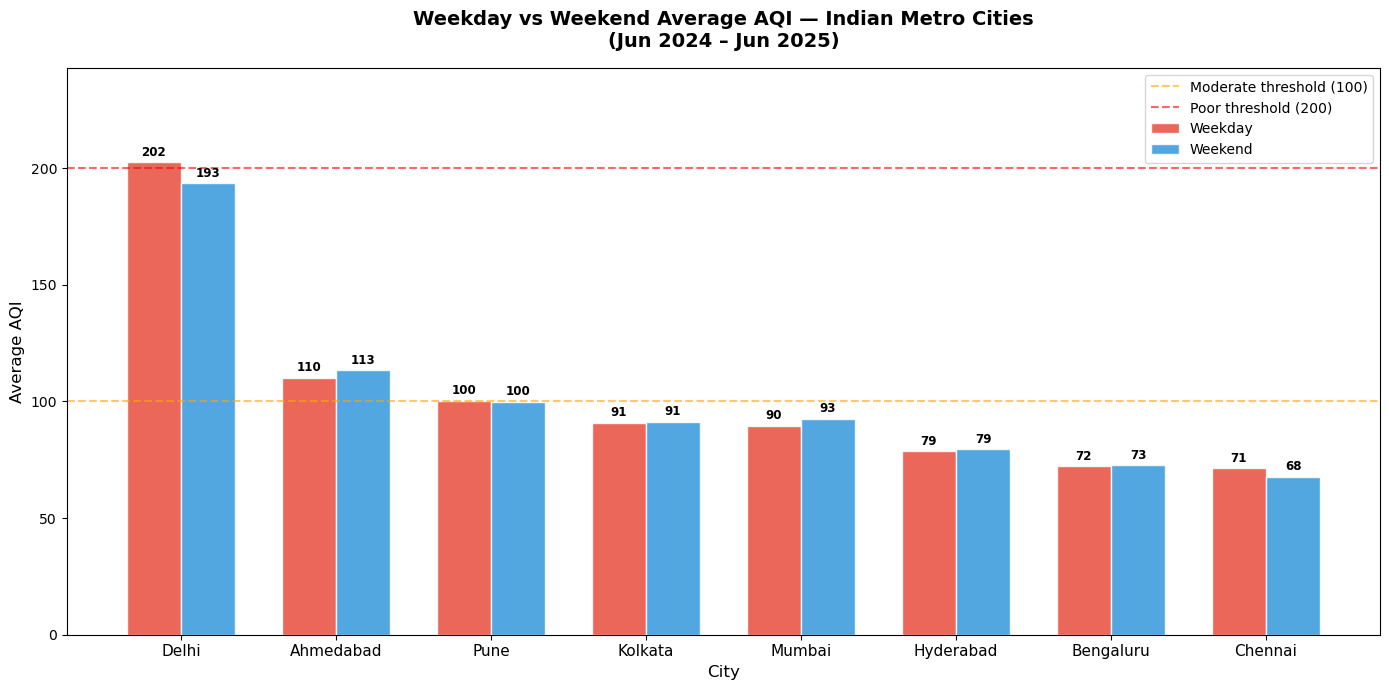

In [7]:

# Pivot for side-by-side bars
pivot = result.pivot(index='area', columns='day_type', values='avg_aqi')
pivot = pivot.sort_values('Weekday', ascending=False)  # sort by weekday AQI

cities = pivot.index
x = np.arange(len(cities))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width/2, pivot['Weekday'], width,
               label='Weekday', color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, pivot['Weekend'], width,
               label='Weekend', color='#3498db', alpha=0.85, edgecolor='white')

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# AQI threshold lines
ax.axhline(y=100, color='orange', linestyle='--', alpha=0.6, label='Moderate threshold (100)')
ax.axhline(y=200, color='red', linestyle='--', alpha=0.6, label='Poor threshold (200)')

ax.set_title('Weekday vs Weekend Average AQI — Indian Metro Cities\n(Jun 2024 – Jun 2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cities, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, pivot.max().max() * 1.2)

plt.tight_layout()
#plt.savefig('images/weekday_weekend_aqi.png', dpi=150, bbox_inches='tight')
plt.show()




#### Key Insights


```
Delhi Weekday AQI : 202.4  ←  "Poor" category
Delhi Weekend AQI : 193.4  ←  still "Very Poor" boundary

Every other city:  61 – 113 range
```
1. Delhi's AQI is **2.5x higher than the next worst city (Ahmedabad at 110)**. Even on weekends when industrial and commercial activity drops, Delhi barely dips below the "Poor" threshold. This is not a traffic problem — it's a structural, multi-source pollution crisis.

> **Business Implication:** Delhi is the single highest-priority launch market in India. The severity is so persistent that even weekend AQI reduction (only 4.5% improvement) confirms pollution sources extend far beyond daily commuter traffic — crop burning, industrial emissions, and construction are continuous contributors. Product messaging in Delhi should emphasise **24/7 protection**, not seasonal or situational use.

2. Cities where Weekend AQI is lower than weekdays are **Delhi(4.5% improvement),Chennai(5.2% improvement),Pune(0.5% improvement-negligible)
3. **5 out of 8 cities show worse AQI on weekends** is counterintuitive and highly significant. It suggests pollution in these cities are driven more by **Industrial activity,construction and non-traffic sources** than by commuter vehicles.

> **Business Implication:** The common assumption that **weekends = cleaner air** is false for most India metros. This invalidates a seasonal or weekday-only use case. AirPure's marketing should not position the product as commuter-hours solution - it needs to be positioned as an **always-on home necessity.** 

The "weekend effect" - the assumption that reduced weekday activity leads to cleaner weekend air- does not hold true in 5 of 8 India's major metros. India's urban air quality crisis is structural and continours , not cyclical. This positions AirPure not as a seasonal or situational product but as a permanent household utility - as essential as a water purifier.